In [1]:
from astropy.io import ascii
from astropy import units as u
from astropy.coordinates import SkyCoord
from gammapy.stats import WStatCountsStatistic
import numpy as np
from gammapy.modeling.models import PowerLawSpectralModel, LogParabolaSpectralModel
import os
import sys
from default_config import DEFAULT_CONFIG
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table
import naima
from main.models import HadronicModel, lnprior_HadronicModel, default_params_HadronicModel
from main.utils import get_BIC, get_parameters, plot_hadronic_model
from naima.models import ExponentialCutoffPowerLaw, BrokenPowerLaw, LogParabola, PionDecay, PowerLaw, InverseCompton, Synchrotron

# Go one directory up (to project root) and add it to Python’s search path
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

def plot_data_script(ax, data, color, marker, energy_unit, flux_unit, label):
    keywords_ul = {
        "capsize": 3, "marker": ".", "elinewidth": 1,
        "zorder": 2, "markersize": 0, "xerr": None
    }

    # --- UL mask ---
    mask_ul = np.asarray(data["ul"], dtype=bool) if "ul" in data.colnames else np.zeros(len(data), dtype=bool)

    # --- Energy: prefer 'energy', else compute from edges ---
    if "energy" in data.colnames:
        E = data["energy"].to(energy_unit)
        xerr = None
    elif ("energy_edge_lo" in data.colnames) and ("energy_edge_hi" in data.colnames):
        Elo = data["energy_edge_lo"].to(energy_unit)
        Ehi = data["energy_edge_hi"].to(energy_unit)
        # bin center (geometric mean) is typical for log-spaced spectra
        E = np.sqrt(Elo * Ehi)
        xerr = np.vstack([(E - Elo).value, (Ehi - E).value])
    else:
        raise KeyError("Need either 'energy' or both 'energy_edge_lo' and 'energy_edge_hi' columns.")

    # --- Flux ---
    F = data["flux"].to(flux_unit)

    # --- Flux errors: symmetric or asymmetric ---
    has_sym = "flux_error" in data.colnames
    has_asym = ("flux_error_lo" in data.colnames) and ("flux_error_hi" in data.colnames)

    yerr = None
    if has_sym:
        dF = data["flux_error"].to(flux_unit)
        yerr = dF[~mask_ul]
    elif has_asym:
        dFlo = np.abs(data["flux_error_lo"].to(flux_unit))
        dFhi = np.abs(data["flux_error_hi"].to(flux_unit))
        yerr = [dFlo[~mask_ul], dFhi[~mask_ul]]

    # --- Plot detections ---
    ax.errorbar(
        E[~mask_ul].to_value(energy_unit),
        F[~mask_ul].to_value(flux_unit),
        yerr=None if yerr is None else (
            yerr.to_value(flux_unit) if has_sym else
            [yerr[0].to_value(flux_unit), yerr[1].to_value(flux_unit)]
        ),
        fmt=marker,
        markersize=6,
        markerfacecolor="white",
        color=color,
        ls="",
        capsize=3,
        label=label,
    )

    # --- Plot upper limits ---
    if np.any(mask_ul):
        # For UL yerr: keep your 0.3*flux convention (or replace with a column if you have one)
        ax.errorbar(
            E[mask_ul].to_value(energy_unit),
            F[mask_ul].to_value(flux_unit),
            yerr=(0.3 * F[mask_ul]).to_value(flux_unit),
            uplims=True,
            color=color,
            ls="",
            **keywords_ul,
        )



/nevis/ged/share/src/conda_envs/vegas/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fermi_data1 = ascii.read('datafiles/4fgl-fermi_above100MeV.dat')
fermi_data2 = ascii.read('datafiles/4fgl-fermi_magichotspot.dat')
fermi_old = ascii.read('datafiles/Fermi_Total.dat')
magic_old = ascii.read('datafiles/MAGIC_Total.dat')
fermi_hotspot = ascii.read("datafiles/Data_points_Fermi_Gaussian.dat")
magic_hotspot = ascii.read("datafiles/Data_points_MAGIC_Gaussian.dat")
veritas_ruo_all = ascii.read('datafiles/naima_VERITAS_ED_v2.dat')
veritas_ruo_arc = ascii.read('datafiles/naima_VERITAS_Arc.dat')
veritas_ruo_hotspot = ascii.read('datafiles/naima_VERITAS_MAGIC.dat')
veritas_ruo_shell = ascii.read('datafiles/naima_VERITAS_Shell.dat')
veritas_vegas_data = ascii.read('datafiles/VERITAS_vegas_4T.dat')
veritas_vegas_hotspot = ascii.read('datafiles/VERITAS_vegas_hotspot.dat')
hawc_data  = ascii.read('datafiles/HAWC_correctformatdata_v2.dat')
xray_data  = ascii.read('datafiles/xray.dat')

fermi_data1['ul'] = fermi_data1['ul'].astype(bool)
fermi_data2['ul'] = fermi_data2['ul'].astype(bool)
fermi_old['ul'] = fermi_old['ul'].astype(bool)
hawc_data['ul'] = hawc_data['ul'].astype(bool)
veritas_ruo_all['ul'] = veritas_ruo_all['ul'].astype(bool)
veritas_vegas_data['ul'] = veritas_vegas_data['ul'].astype(bool)
veritas_vegas_hotspot['ul'] = veritas_vegas_hotspot['ul'].astype(bool)
# new fermi data
#fit_dic = {'Fermi-LAT_Above100MeV (preliminary)':fermi_data1, 'Fermi-LAT_Above10GeV (preliminary)':fermi_data2, 'HAWC (preliminary)': hawc_data, 'VERITAS (EventDisplay)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data}

# old fermi & magic data without hawc
#fit_dic = {'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
#           'VERITAS (ED & Matrix)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data}

# old fermi & magic data with new hawc and x-ray data
fit_dic = {'X-ray': xray_data, 'Fermi-LAT (2023)':fermi_old, 'MAGIC (2023)': magic_old,
           'VERITAS (ED & Matrix)': veritas_ruo_all, 'VERITAS (VEGAS)': veritas_vegas_data, 'HAWC (preliminary)': hawc_data}

#fit_dic = {'Fermi-LAT (2023)':fermi_hotspot, 'MAGIC (2023)': magic_hotspot,
#           'VERITAS (ED & Matrix)': veritas_ruo_hotspot, 'VERITAS (VEGAS)': veritas_vegas_hotspot}


## Convert Flux to SED

In [3]:
def add_energy_from_edges(tbl,
                          lo_candidates=("energy_edge_lo", "energy_lo", "emin", "e_min", "EBinLowEdge", "Emin"),
                          hi_candidates=("energy_edge_hi", "energy_hi", "emax", "e_max", "EBinHiEdge", "Emax"),
                          method="log",          # "log" or "linear"
                          energy_unit=u.TeV,     # used if edges have no units
                          outcol="energy"):
    """
    Create `outcol` (default: 'energy') from low/high bin edges in an astropy Table.

    Parameters
    ----------
    tbl : astropy.table.Table
    method : str
        "log" -> sqrt(E_lo * E_hi) (geometric mean), preferred
        "linear" -> 0.5*(E_lo + E_hi)
    energy_unit : astropy.unit.Unit
        Used only if edge columns are unitless
    """

    def _first_existing(cands):
        for c in cands:
            if c in tbl.colnames:
                return c
        return None

    lo = _first_existing(lo_candidates)
    hi = _first_existing(hi_candidates)

    if lo is None or hi is None:
        raise KeyError(
            f"Could not find both edge columns. Found lo={lo}, hi={hi}. Available: {tbl.colnames}"
        )

    Elo = tbl[lo]
    Ehi = tbl[hi]

    # Attach units if missing
    if getattr(Elo, "unit", None) is None:
        Elo = Elo * energy_unit
    else:
        Elo = Elo.quantity.to(energy_unit)

    if getattr(Ehi, "unit", None) is None:
        Ehi = Ehi * energy_unit
    else:
        Ehi = Ehi.quantity.to(energy_unit)

    # Safety: avoid non-positive values in log-centering
    if method == "log":
        if np.any(Elo <= 0) or np.any(Ehi <= 0):
            raise ValueError("Non-positive energy edges encountered; cannot use log-centering.")
        E = np.sqrt(Elo * Ehi)
    elif method == "linear":
        E = 0.5 * (Elo + Ehi)
    else:
        raise ValueError("method must be 'log' or 'linear'")

    tbl[outcol] = E.to(energy_unit)

    # Optional extras that can be handy later
    tbl["energy_width"] = (Ehi - Elo).to(energy_unit)
    tbl["energy_edge_lo"] = Elo.to(energy_unit)
    tbl["energy_edge_hi"] = Ehi.to(energy_unit)

    return tbl

In [4]:
for name, tbl in fit_dic.items():
    if "energy" not in tbl.colnames:
        fit_dic[name] = add_energy_from_edges(tbl, method="log", energy_unit=u.TeV)

In [5]:
for k, t in fit_dic.items():
    print(k, t["flux"].unit, t["flux"].unit.physical_type)

X-ray erg / (s cm2) energy flux/flux/irradiance
Fermi-LAT (2023) eV / (s cm2) energy flux/flux/irradiance
MAGIC (2023) eV / (s cm2) energy flux/flux/irradiance
VERITAS (ED & Matrix) TeV / (s cm2) energy flux/flux/irradiance
VERITAS (VEGAS) 1 / (TeV s cm2) differential flux
HAWC (preliminary) TeV / (s cm2) energy flux/flux/irradiance


In [6]:
def convert_to_sed(table, target=u.TeV/(u.cm**2*u.s), energy_unit=u.TeV):
    """
    Convert table['flux'] to SED (E^2 dN/dE) and standardize to `target`.
    - If flux already SED-like: just convert units to target.
    - If flux is differential flux: compute sed = E^2 * flux.
    Also forces table['energy'] to be a real energy Quantity.
    """
    t = table.copy()

    # --- Force energy to be an energy quantity ---
    E = t["energy"].quantity if hasattr(t["energy"], "quantity") else t["energy"] * energy_unit

    # If energy column has a bogus unit (e.g. energy flux), strip and reattach:
    if hasattr(E, "unit"):
        if E.unit.physical_type != "energy":
            # interpret stored values as numeric energies in `energy_unit`
            E = u.Quantity(t["energy"].data, energy_unit)
    else:
        E = u.Quantity(t["energy"], energy_unit)

    E = E.to(energy_unit)
    t["energy"] = E  # overwrite with corrected energy column

    # --- Get flux as a Quantity ---
    F = t["flux"].quantity if hasattr(t["flux"], "quantity") else u.Quantity(t["flux"], target)

    # Case 1: already SED-like (energy flux / power per area)
    if F.unit.physical_type in ("energy flux", "flux", "irradiance", "power"):
        t["flux"] = F.to(target)

        if "flux_error" in t.colnames:
            Fe = t["flux_error"].quantity
            t["flux_error"] = Fe.to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = t["flux_error_lo"].quantity.to(target)
            t["flux_error_hi"] = t["flux_error_hi"].quantity.to(target)

        return t

    # Case 2: differential flux -> SED
    if F.unit.physical_type == "differential flux":
        sed = (E**2 * F).to(target)
        t["flux"] = sed

        if "flux_error" in t.colnames:
            t["flux_error"] = (E**2 * t["flux_error"].quantity).to(target)

        if "flux_error_lo" in t.colnames and "flux_error_hi" in t.colnames:
            t["flux_error_lo"] = (E**2 * t["flux_error_lo"].quantity).to(target)
            t["flux_error_hi"] = (E**2 * t["flux_error_hi"].quantity).to(target)

        return t

    raise ValueError(f"Unrecognized flux physical_type: {F.unit.physical_type} (unit={F.unit})")


In [7]:
for name, table in fit_dic.items():
    fit_dic[name] = convert_to_sed(table)
    print(name, fit_dic[name]["flux"].unit)

X-ray TeV / (s cm2)
Fermi-LAT (2023) TeV / (s cm2)
MAGIC (2023) TeV / (s cm2)
VERITAS (ED & Matrix) TeV / (s cm2)
VERITAS (VEGAS) TeV / (s cm2)
HAWC (preliminary) TeV / (s cm2)


# LHAASO data

In [8]:
wcda_pl = PowerLawSpectralModel(index = 2.91*u.Unit(''), 
                                    amplitude=2.36*1e-13 * u.Unit('TeV-1 cm-2 s-1'),
                                   reference=3*u.TeV)


wcda_pl.covariance = np.array([[np.square(0.06), 0, 0],\
                               [0, np.square(0.16*1e-13), 0], [0,0,0]])





km2a_pl = PowerLawSpectralModel(index = 3.56*u.Unit(''), 
                                    amplitude=0.35*1e-16 * u.Unit('TeV-1 cm-2 s-1'),
                                   reference=50*u.TeV)


km2a_pl.covariance = np.array([[np.square(0.23), 0, 0],\
                               [0, np.square(0.05*1e-16), 0], [0,0,0]])


# Modeling

In [9]:
# --- Power-law model: dN/dE = N0 * (E/E0)^(-Gamma)
def dnde_powerlaw(E, N0, E0, Gamma):
    return N0 * (E / E0) ** (-Gamma)

def e2_dnde(E, K, E0, Gamma):
    return (E**2) * dnde_powerlaw(E, K, E0, Gamma)

def e2_dnde_sigma(E, N0, dN0, E0, Gamma, dGamma):
    """
    1σ for y = E^2 * N0 * (E/E0)^(-Gamma), assuming N0 and Gamma uncorrelated.
    ln y = ln N0 + 2 ln E - Gamma ln(E/E0)  ->  σ_y / y = sqrt( (σ_N0/N0)^2 + (ln(E/E0) σ_Gamma)^2 )
    """ 
    y = e2_dnde(E, N0, E0, Gamma)
    lnEE0 = np.log(E / E0)
    rel2  = (dN0 / N0)**2 + (lnEE0 * dGamma)**2
    return y * np.sqrt(rel2)
    

In [10]:
# datatable construction required for naima modeling
datatable = []
for keys in fit_dic.keys():
    datatable.append(fit_dic[keys])

In [11]:
from main.models import LeptonicModel, lnprior_LeptonicModel, default_params_LeptonicModel
model_type = "ECPL"
gas_density = 2.5 * u.cm**-3
distance = 2 * u.kpc



def LeptonicModel_wrapper(pars, data):
    return LeptonicModel(pars, data, model_type=model_type, distance=distance)[0]
    # [0] because LeptonicModel returns (model_flux, (eE, eDist), We)

def lnprior_wrapper(pars):
    return lnprior_LeptonicModel(pars, model_type=model_type)

p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    data_sed=True,
    prefit=True,
)


INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [39.39648405  2.          1.        ] [naima.core]
INFO:    Initial lnprob(p0): -532527130446.242 [naima.core]
INFO:    New ML parameters : [35.74142004  2.77370836  0.88607788] [naima.core]
INFO:    Maximum lnprob(p0): -58.732 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.7            2.78            0.886     
  Last ensemble std    :      0.136          0.0167          0.00435    
  Last ensemble lnprob :  avg: -103.431, max: -58.600

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.8            2.77            0.886     
  Last ensemble std    :      0.115          0.0227          0.00455  

In [12]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(35.74902209962366), 'err_low': np.float64(0.027697820104009452), 'err_high': np.float64(0.02839293048591429)}, 'alpha': {'median': np.float64(2.845420840550654), 'err_low': np.float64(0.06735587769066997), 'err_high': np.float64(0.05778421640743803)}, 'log10(cutoff_energy)': {'median': np.float64(0.9221286465732867), 'err_low': np.float64(0.03208627767448469), 'err_high': np.float64(0.03851070373700605)}}


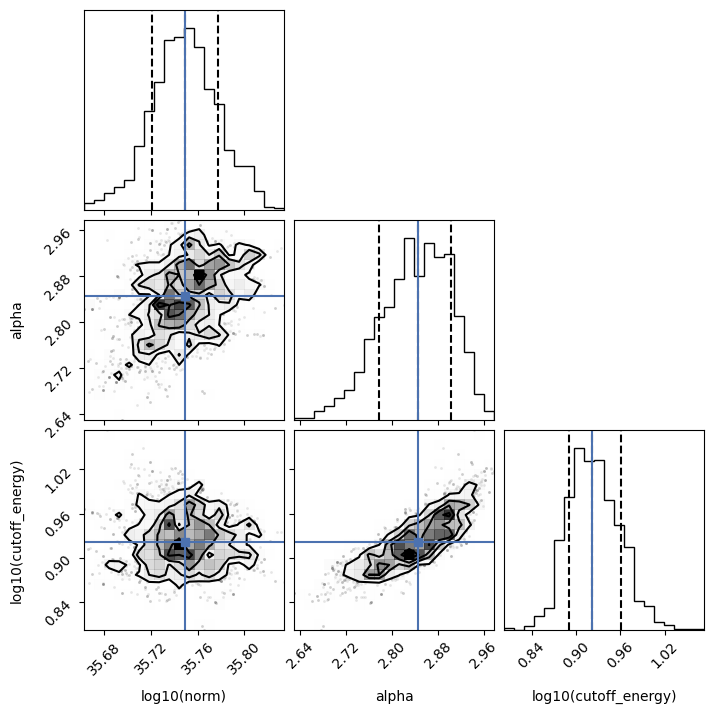

In [13]:
from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)
plt.savefig("corner_leptonic.png")

In [14]:
get_BIC(sampler)

BIC value for model: 121.052


In [15]:
#naima.plot_fit(sampler, sed=True, n_samples=100, plotdata=True, plotresiduals=None, e_unit=u.TeV, xlabel=None, ylabel=None, ulim_opts={}, errorbar_opts={})

Electron log10(norm): 35.74902209962366 (-0.027697820104009452 + 0.02839293048591429)
Electron spectral index alpha: 2.845420840550654 (-0.06735587769066997 + 0.05778421640743803)

[Gamma-ray spectrum (Leptonic IC)]
dN/dE (1 TeV): 3.645e-12 1 / (TeV s cm2) (-4.030e-14 1 / (TeV s cm2), +1.833e-13 1 / (TeV s cm2))
E^2 dN/dE (1 TeV): 3.645e-12 TeV / (s cm2) (-4.030e-14 TeV / (s cm2), +1.833e-13 TeV / (s cm2))
Gamma-ray index @1 TeV: 2.822 (--0.021, +-0.031)
Estimated gamma-ray break from modeled IC spectrum: 14.803 TeV (-0.000 TeV, +0.000 TeV)
Local gamma-ray indices from IC model: low=1.941, high=9.089
Total electron energy We (>1 GeV): 3.648e+50 erg (-1.316e+50 erg, +1.790e+50 erg)


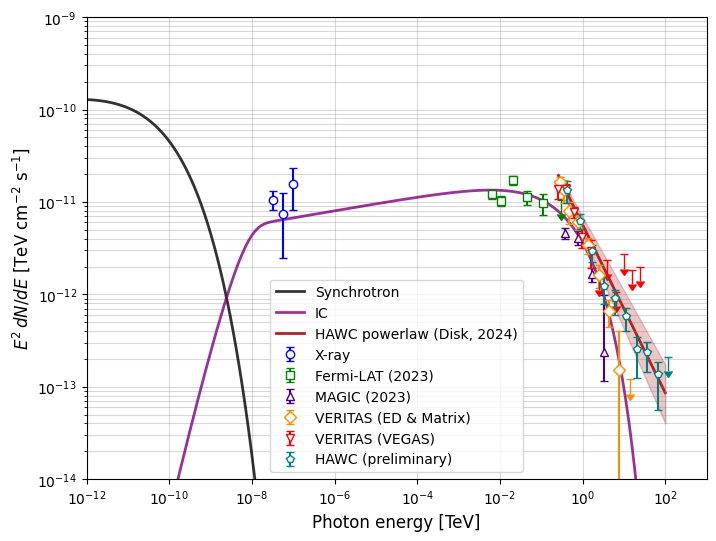

In [16]:
print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
#print(f"Electron spectral index beta: {MLp_dict['beta']['median']} (-{MLp_dict['beta']['err_low']} + {MLp_dict['beta']['err_high']})")
#print(f"Electron log10(break_energy): {MLp_dict['log10(break_energy)']['median']} (-{MLp_dict['log10(break_energy)']['err_low']} + {MLp_dict['log10(break_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"],
                    energy_range=(1e-12, 1e3), label="Leptonic model", color="purple", ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

#ax.set_xlim(left=1e-9)
ax.legend()

plt.show()
#plt.savefig('leptonic_bpl.png')

In [20]:
model_type = "ECPL"
gas_density = 20 * u.cm**-3
distance = 2 * u.kpc


p0    = default_params_LeptonicModel[model_type]["p0"]
labels = default_params_LeptonicModel[model_type]["labels"]

sampler, pos = naima.run_sampler(
    data_table=datatable,
    p0=p0,
    labels=labels,
    model=LeptonicModel_wrapper,
    prior=lnprior_wrapper,
    nwalkers=32,
    nburn=20,
    nrun=100,
    threads=4,
    prefit=True,
)



INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [38.55758809  2.          1.        ] [naima.core]
INFO:    Initial lnprob(p0): -11179780884.867 [naima.core]
INFO:    New ML parameters : [35.68889158  2.63621587  0.84249975] [naima.core]
INFO:    Maximum lnprob(p0): -53.202 [naima.core]
Burning in the 32 walkers with 20 steps...

Progress of the run: 0 percent (0 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.7            2.63            0.843     
  Last ensemble std    :      0.153           0.014          0.00386    
  Last ensemble lnprob :  avg: -114.224, max: -53.263

Progress of the run: 5 percent (1 of 20 steps)
                           --log10(norm)-- -----alpha----- log10(cutoff_energy)
  Last ensemble median :      35.7            2.64            0.843     
  Last ensemble std    :      0.143          0.0143          0.00557   

Best fit parameters for Leptonic Model:
{'log10(norm)': {'median': np.float64(35.69755691927981), 'err_low': np.float64(0.03632638429980517), 'err_high': np.float64(0.036812673011162644)}, 'alpha': {'median': np.float64(2.672087235800819), 'err_low': np.float64(0.10217454878236332), 'err_high': np.float64(0.11281589954320204)}, 'log10(cutoff_energy)': {'median': np.float64(0.8596928979837442), 'err_low': np.float64(0.05386415881821072), 'err_high': np.float64(0.0533910070874678)}}
BIC value for model: 116.885
Electron log10(norm): 35.69755691927981 (-0.03632638429980517 + 0.036812673011162644)
Electron spectral index alpha: 2.672087235800819 (-0.10217454878236332 + 0.11281589954320204)
Electron log10(cutoff_energy): 0.8596928979837442 (-0.05386415881821072 + 0.0533910070874678)

[Gamma-ray spectrum (Leptonic IC)]
dN/dE (1 TeV): 3.950e-12 1 / (TeV s cm2) (-2.139e-13 1 / (TeV s cm2), +1.640e-14 1 / (TeV s cm2))
E^2 dN/dE (1 TeV): 3.950e-12 TeV / (s cm2) (-2.139e-13 TeV / (s cm2), +1.640e

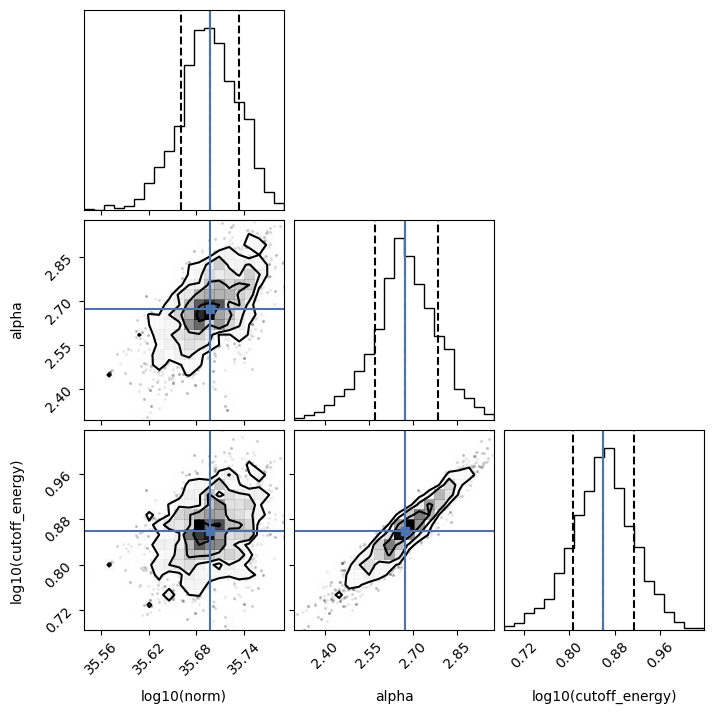

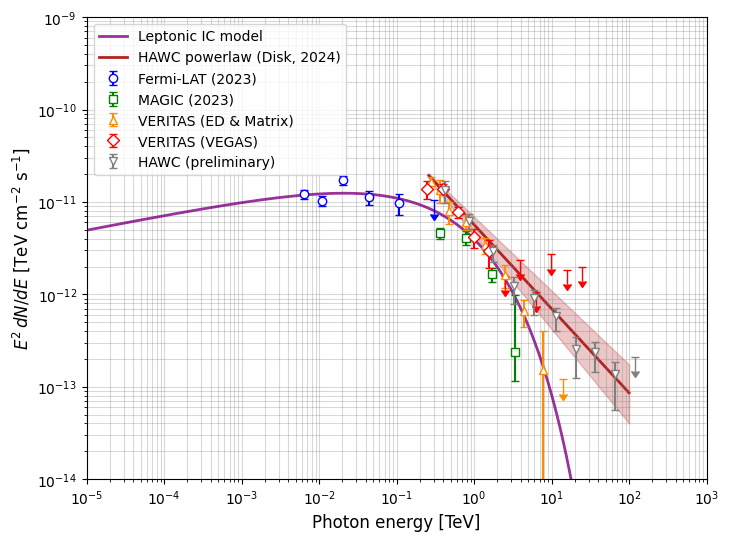

In [22]:
MLp_dict = get_parameters(sampler, ML=False)
print("Best fit parameters for Leptonic Model:")
print(MLp_dict)
medians = {key: val["median"] for key, val in MLp_dict.items()}

from corner import corner
color_cycle = [
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
            (0.5058823529411764, 0.4470588235294118, 0.6980392156862745),
            (0.8, 0.7254901960784313, 0.4549019607843137),
            (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
        ]

corner_opts = {
            "labels": sampler.labels,
            "truths": list(medians.values()),
            "quantiles": [0.16, 0.5, 0.84],
            "verbose": False,
            "truth_color": color_cycle[0],
        }

f = corner(sampler.get_chain(flat=True), **corner_opts)

get_BIC(sampler)

print(f"Electron log10(norm): {MLp_dict['log10(norm)']['median']} (-{MLp_dict['log10(norm)']['err_low']} + {MLp_dict['log10(norm)']['err_high']})")
print(f"Electron spectral index alpha: {MLp_dict['alpha']['median']} (-{MLp_dict['alpha']['err_low']} + {MLp_dict['alpha']['err_high']})")
print(f"Electron log10(cutoff_energy): {MLp_dict['log10(cutoff_energy)']['median']} (-{MLp_dict['log10(cutoff_energy)']['err_low']} + {MLp_dict['log10(cutoff_energy)']['err_high']})")

from main.utils import plot_leptonic_model

fig,ax = plt.subplots(figsize=(8,6))
plot_leptonic_model(params_dict=MLp_dict, data_dict=fit_dic, model_type=model_type, distance=distance, seed_photon_fields=["CMB"],
    label="Leptonic IC model",
    color="purple", ax = ax, show=False)

params = {
    "HAWC powerlaw (Disk, 2024)":    dict(E0=1.1, K=4.3e-12, dK=1.0e-12, Gamma=2.91, dGamma=0.11,
                         color="firebrick", ls="-", E_range=(0.26, 100))
}


for name, p in params.items():
    E = np.logspace(np.log10(p["E_range"][0]), np.log10(p["E_range"][1]), 400)
    y = e2_dnde(E, p["K"], p["E0"], p["Gamma"])

    # 1σ confidence band by linear error propagation
    Kp, Km = p["K"] + p["dK"], p["K"] - p["dK"]
    Gp, Gm = p["Gamma"] + p["dGamma"], p["Gamma"] - p["dGamma"]
    y_up = e2_dnde(E, Kp, p["E0"], Gm)   # lower Γ → harder → upper envelope
    y_lo = e2_dnde(E, Km, p["E0"], Gp)

    ax.plot(E, y, color=p["color"], linestyle=p["ls"], lw=2, label=f"{name}", zorder=1) #label="HAWC powerlaw (2024)"
    ax.fill_between(E, y_lo, y_up, color=p["color"], alpha=0.25)

ax.legend()

#plt.show()
plt.savefig('leptonic_ecpl.png')